In [22]:
# =============================================================================
# ML for the Quantified Self – Master Notebook
# Gym Movements Dataset: 2 participants × 3 activities × multiple sessions (LOSO evaluation)
# Models: RF, SVM, GBM | LSTM, CNN-LSTM, TCN
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from Python.integrations import load_gym_dataset
from Python.plots import analyze_data_distribution
from Python.windows import create_adaptive_windows
from Python.feature_engineering import engineer_robust_features
from Python.training import train_with_validation

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# ── 1. LOAD GYM MOVEMENTS DATASET ────────────────────────────────────────────
print("Loading Gym Movements Dataset...")
raw_data = load_gym_dataset(Path("./Datasets/Gym Movements Dataset"))
print(f"\nTotal samples  : {len(raw_data):,}")
print(f"Participants   : {sorted(raw_data['participant'].unique())}")
print(f"Activities     : {sorted(raw_data['activity_label'].unique())}")
print(f"Sessions total : {raw_data['session'].nunique()}")
print(f"Sessions/person: {raw_data.groupby('participant')['session'].nunique().to_dict()}")
print(f"Columns        : {list(raw_data.columns)}")
raw_data.head(3)


Loading Gym Movements Dataset...
Gym Movements Dataset loaded:
  Total samples : 118,031
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'row', 'threadmill']
  Sessions      : 59
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'mag_x', 'mag_y', 'mag_z', 'activity_label', 'participant', 'session', 'data_source']

Total samples  : 118,031
Participants   : ['imaan', 'richard']
Activities     : ['elliptical', 'lat_pull', 'row', 'threadmill']
Sessions total : 59
Sessions/person: {'imaan': 48, 'richard': 11}
Columns        : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'mag_x', 'mag_y', 'mag_z', 'activity_label', 'participant', 'session', 'data_source

,time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,grav_x,grav_y,grav_z,...,orient_roll,orient_pitch,orient_yaw,mag_x,mag_y,mag_z,activity_label,participant,session,data_source
0,0.000000,-0.688212,0.166774,-0.657767,0.013338,-0.156200,-1.396037,-0.949787,1.931225,9.560768,...,0.098527,-0.198835,0.896285,NaN,NaN,NaN,elliptical,imaan,0,original
1,0.409976,-0.068599,4.304119,-2.431066,0.439038,-0.056513,-1.396587,-1.002400,2.138880,9.511066,...,0.104943,-0.220052,0.873502,-7.55625,-8.475,-44.700001,elliptical,imaan,0,original
2,0.419741,2.402801,0.533724,-2.446329,0.791037,0.185212,-0.250250,-1.011801,2.250275,9.484330,...,0.107461,-0.231156,0.856114,-7.55625,-8.475,-44.700001,elliptical,imaan,0,original


In [23]:

# ── 2. MISSING VALUE HANDLING (Point 3) ──────────────────────────────────────
SENSOR_COLS = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z", "grav_x", "grav_y", "grav_z", "orient_qz", "orient_qy", "orient_qx", "orient_qw", "orient_roll", "orient_pitch", "orient_yaw",
                    "mag_x", "mag_y", "mag_z"]

missing = raw_data[SENSOR_COLS].isnull().sum()
print("=== Missing Value Analysis ===")
print(f"Per-channel missing values:\n{missing.to_string()}")
total_missing = int(missing.sum())
print(f"\nTotal missing sensor readings: {total_missing}")

if total_missing > 0:
    print("\nApplying linear interpolation per (participant, session)...")
    raw_data[SENSOR_COLS] = (
        raw_data.groupby(["participant", "session"])[SENSOR_COLS]
        .transform(
            lambda g: g.interpolate(method="linear")
                       .ffill()
                       .bfill()
        )
    )
    remaining = int(raw_data[SENSOR_COLS].isnull().sum().sum())
    print(f"Remaining missing after interpolation: {remaining}")
else:
    print("\nNo missing values detected — dataset is complete.")


=== Missing Value Analysis ===
Per-channel missing values:
acc_x            0
acc_y            0
acc_z            0
gyro_x          25
gyro_y          25
gyro_z          25
grav_x          25
grav_y          25
grav_z          25
orient_qz       26
orient_qy       26
orient_qx       26
orient_qw       26
orient_roll     26
orient_pitch    26
orient_yaw      26
mag_x           43
mag_y           43
mag_z           43

Total missing sensor readings: 461

Applying linear interpolation per (participant, session)...
Remaining missing after interpolation: 0


=== Exploratory Data Analysis ===


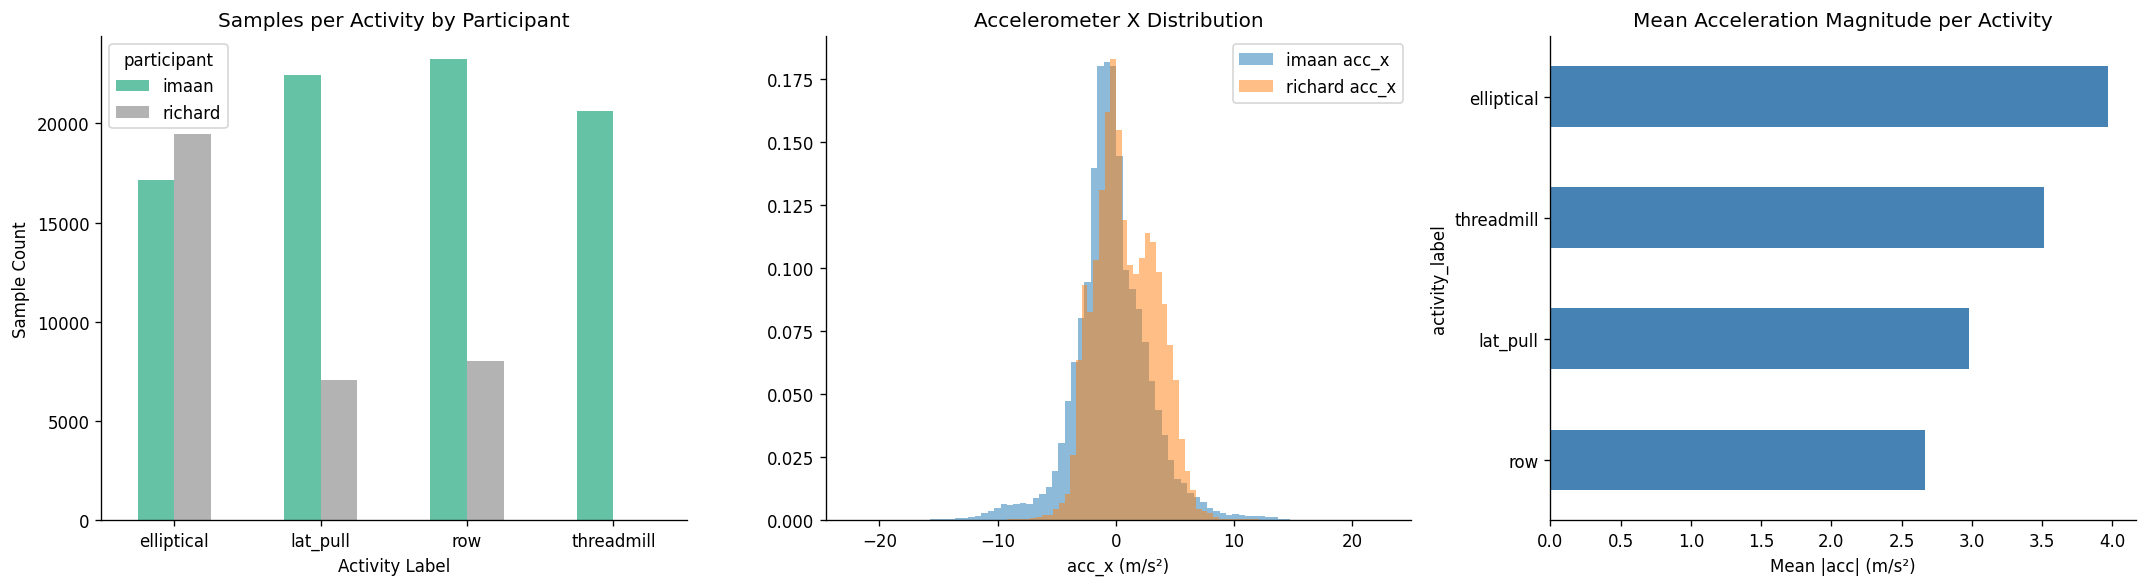


Class balance (samples per activity):
activity_label
elliptical    36635
lat_pull      29514
row           31258
threadmill    20624

Sensor statistics:
            acc_x       acc_y       acc_z      gyro_x      gyro_y      gyro_z      grav_x      grav_y      grav_z   orient_qz   orient_qy   orient_qx   orient_qw  orient_roll  orient_pitch  orient_yaw       mag_x       mag_y       mag_z
count  118031.000  118031.000  118031.000  118031.000  118031.000  118031.000  118031.000  118031.000  118031.000  118031.000  118031.000  118031.000  118031.000   118031.000    118031.000  118031.000  118031.000  118031.000  118031.000
mean        0.012      -0.004      -0.067      -0.002      -0.095       0.128       0.589      -3.492       5.193      -0.064      -0.017      -0.169       0.715       -0.104         0.401       0.034      -8.739      33.314     -23.819
std         3.135       1.621       1.877       2.214       2.007       1.805       5.865       3.690       2.925       0.430       0.3

In [24]:

# ── 3. EXPLORATORY DATA ANALYSIS (Point 2) ───────────────────────────────────
print("=== Exploratory Data Analysis ===")

# Activity label distribution
if "activity_label" in raw_data.columns:
    act_col = "activity_label"
elif "activity" in raw_data.columns:
    act_col = "activity"
else:
    raise RuntimeError("No activity label column found in raw_data.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Samples per activity
act_counts = raw_data.groupby([act_col, "participant"]).size().unstack(fill_value=0)
act_counts.plot(kind="bar", ax=axes[0], colormap="Set2")
axes[0].set_title("Samples per Activity by Participant")
axes[0].set_xlabel("Activity Label")
axes[0].set_ylabel("Sample Count")
axes[0].tick_params(axis="x", rotation=0)

# (b) Accelerometer distributions
for p, ls in zip(sorted(raw_data["participant"].unique()), ["-", "--"]):
    pdata = raw_data[raw_data["participant"] == p]
    axes[1].hist(pdata["acc_x"], bins=80, alpha=0.5, density=True, label=f"{p} acc_x", linestyle=ls)
axes[1].set_title("Accelerometer X Distribution")
axes[1].set_xlabel("acc_x (m/s²)")
axes[1].legend()

# (c) Gyroscope by activity (mean acc magnitude)
raw_data["acc_mag"] = np.sqrt(
    raw_data["acc_x"]**2 + raw_data["acc_y"]**2 + raw_data["acc_z"]**2
)
act_mag = raw_data.groupby(act_col)["acc_mag"].mean().sort_values()
act_mag.plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Mean Acceleration Magnitude per Activity")
axes[2].set_xlabel("Mean |acc| (m/s²)")

plt.tight_layout()
plt.savefig("./Plots/field_data_eda.png", dpi=150, bbox_inches="tight")
plt.show()

# Class balance report
print("\nClass balance (samples per activity):")
print(raw_data[act_col].value_counts().sort_index().to_string())
print(f"\nSensor statistics:\n{raw_data[SENSOR_COLS].describe().round(3).to_string()}")


In [25]:

# ── 4. WINDOWING & FEATURE ENGINEERING (Point 4) ─────────────────────────────
print("=== Windowing ===")
windowed_data = create_adaptive_windows(
    raw_data,
    min_window_size=64,
    preferred_window_size=128,   # 2.56 s @ 50 Hz
    overlap_ratio=0.5,
)

print("\n=== Feature Engineering ===")
features, labels, feature_names, metadata = engineer_robust_features(
    windowed_data, sampling_rate=50
)

print(f"\nFeature matrix shape: {features.shape}")
print(f"Label distribution  : {dict(zip(*np.unique(labels, return_counts=True)))}")

participants = np.array([m["participant"] for m in metadata])
print(f"Windows per participant: "
      f"{dict(zip(*np.unique(participants, return_counts=True)))}")


=== Windowing ===

Window creation summary:
  Full-size windows: 1758
  Adaptive windows: 0
  Rejected segments: 0
  Total windows: 1758

=== Feature Engineering ===
  Processing window 0/1758...
  Processing window 100/1758...
  Processing window 200/1758...
  Processing window 300/1758...
  Processing window 400/1758...
  Processing window 500/1758...
  Processing window 600/1758...
  Processing window 700/1758...
  Processing window 800/1758...
  Processing window 900/1758...
  Processing window 1000/1758...
  Processing window 1100/1758...
  Processing window 1200/1758...
  Processing window 1300/1758...
  Processing window 1400/1758...
  Processing window 1500/1758...
  Processing window 1600/1758...
  Processing window 1700/1758...

Feature matrix shape: (1758, 145)
Label distribution  : {np.str_('elliptical'): np.int64(550), np.str_('lat_pull'): np.int64(437), np.str_('row'): np.int64(465), np.str_('threadmill'): np.int64(306)}
Windows per participant: {np.str_('imaan'): np.int6

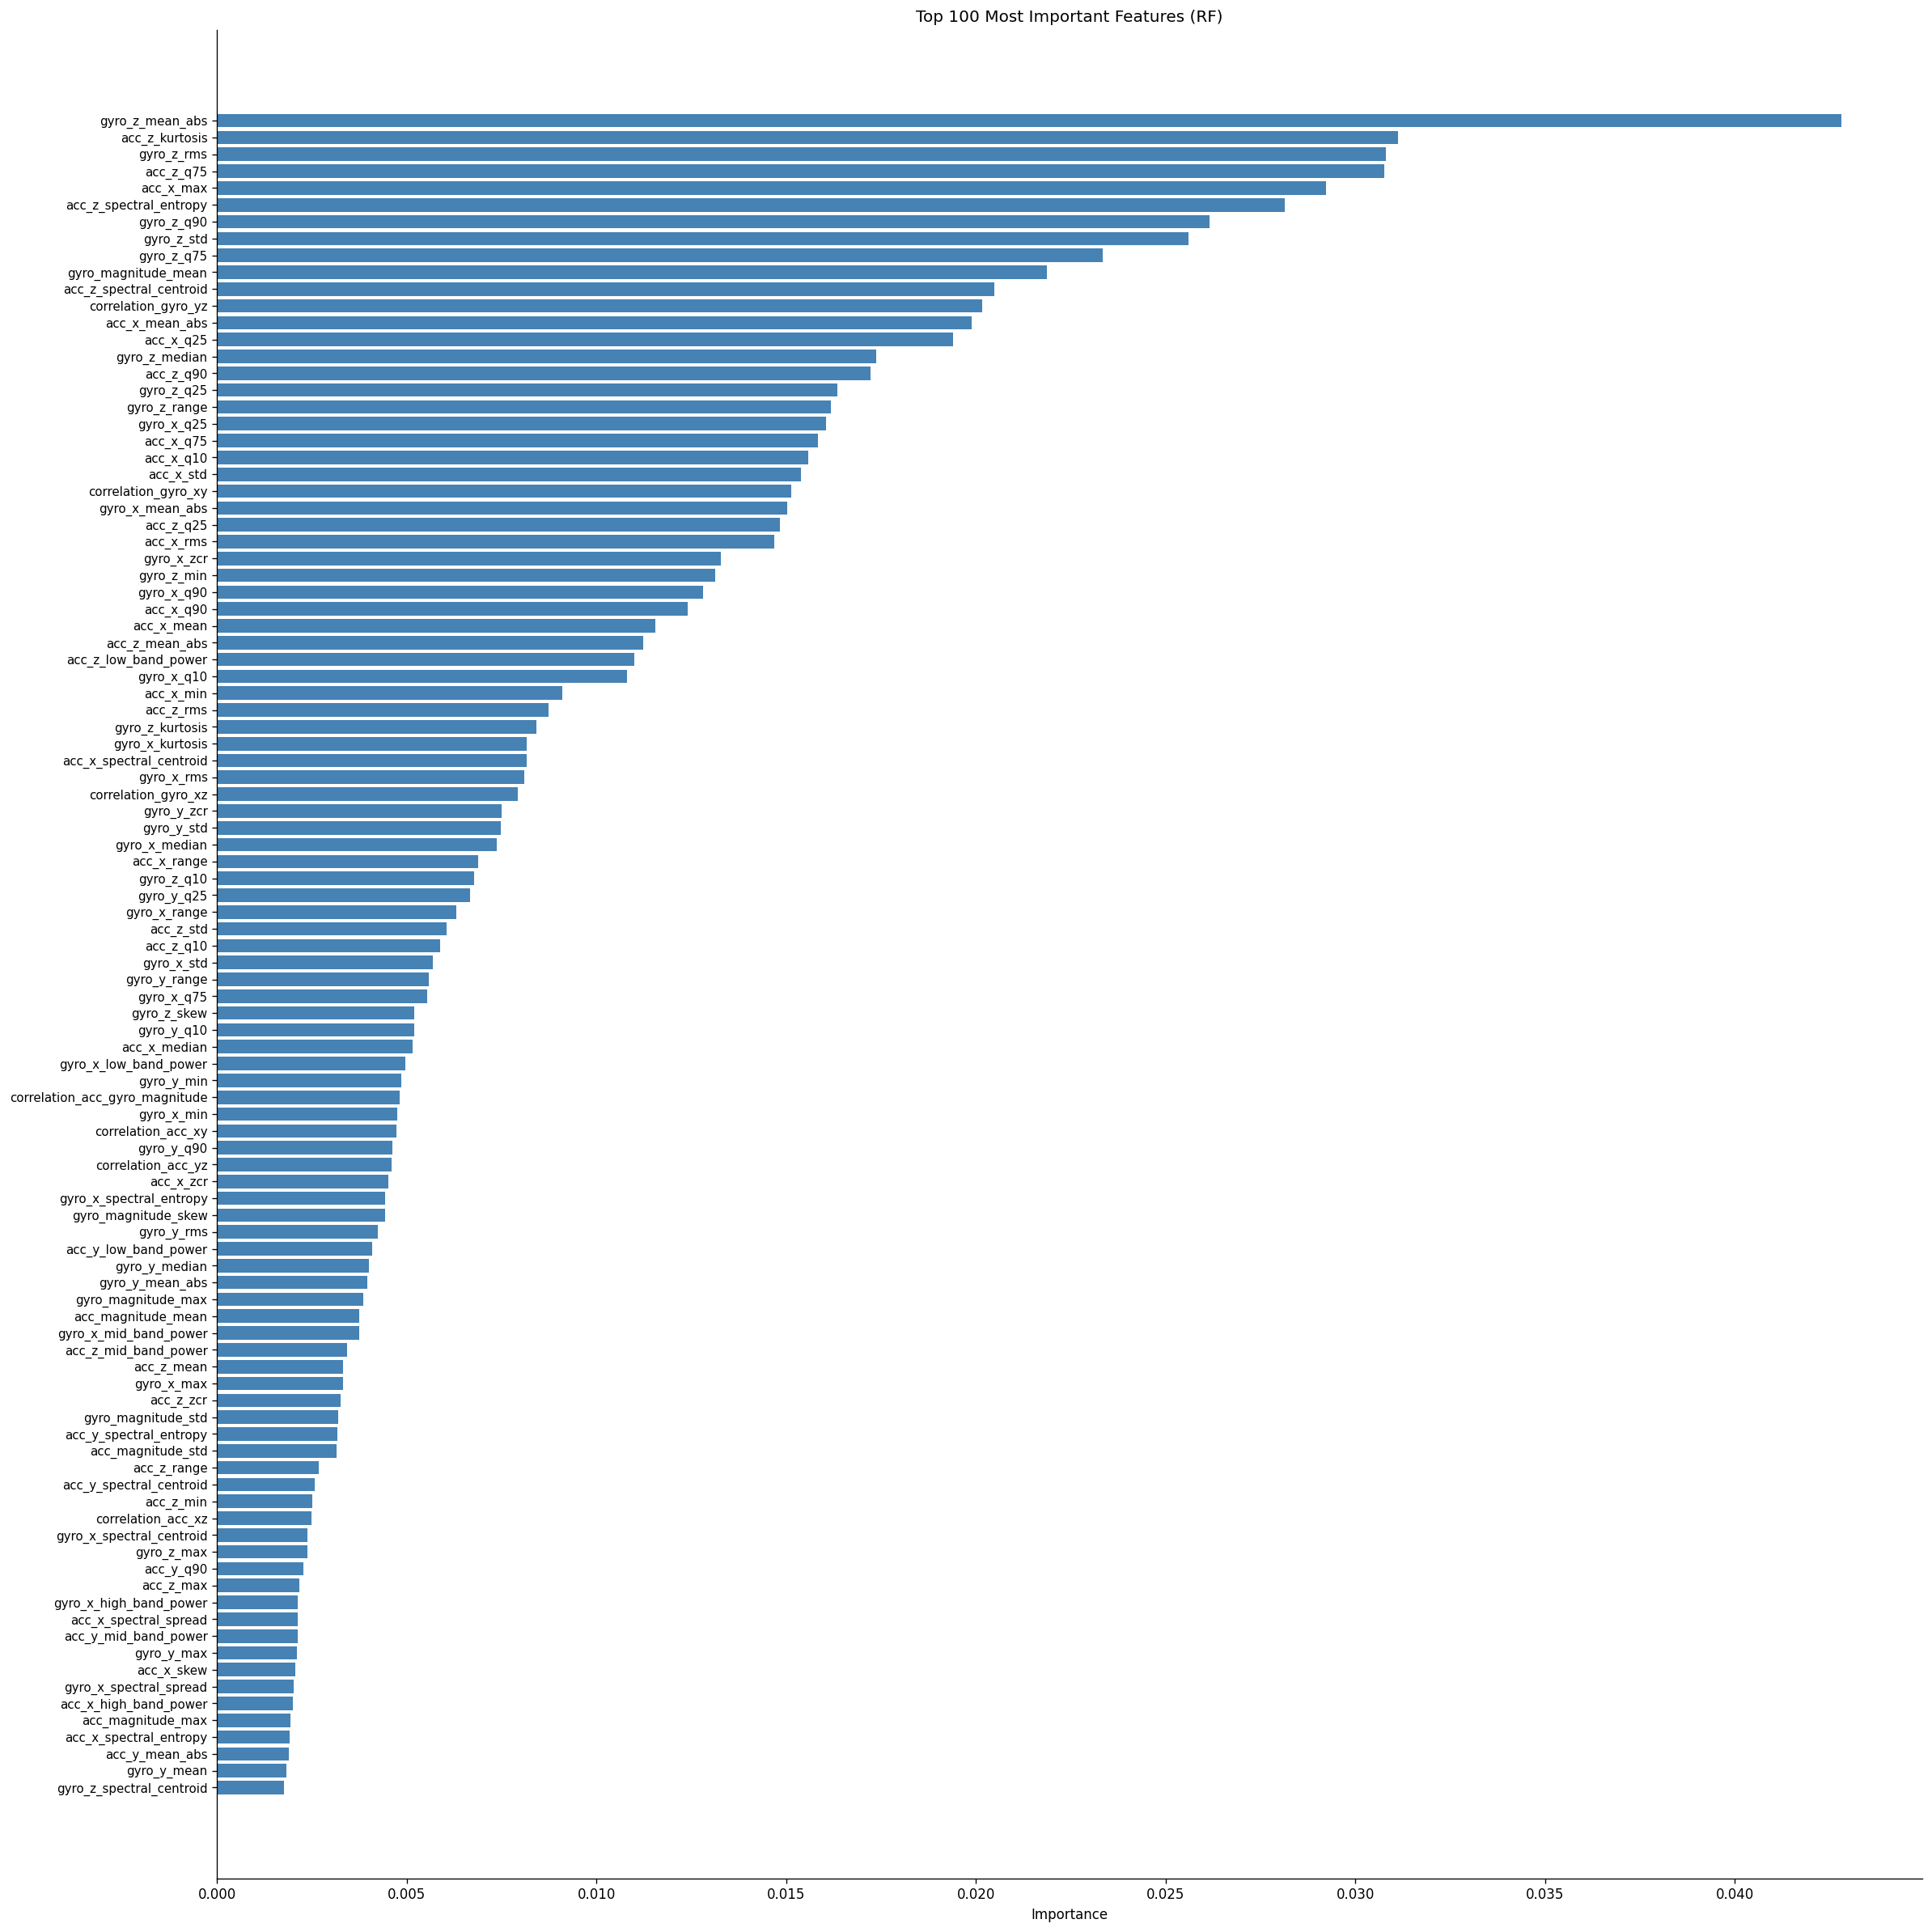

Top 5 features:
  1. gyro_z_mean_abs                          0.0428
  2. acc_z_kurtosis                           0.0311
  3. gyro_z_rms                               0.0308
  4. acc_z_q75                                0.0308
  5. acc_x_max                                0.0292


In [26]:

# ── 5. FEATURE IMPORTANCE (Point 4) ──────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Quick RF for feature importance (stratified, not the final eval split)
scaler_tmp = StandardScaler()
feat_scaled = scaler_tmp.fit_transform(features)

rf_tmp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_tmp.fit(feat_scaled, labels)

importances = rf_tmp.feature_importances_
top_k = 100
top_idx = np.argsort(importances)[-top_k:][::-1]

fig, ax = plt.subplots(figsize=(20, 20))
ax.barh(
    range(top_k),
    importances[top_idx][::-1],
    color="steelblue",
)
ax.set_yticks(range(top_k))
ax.set_yticklabels([feature_names[i] for i in top_idx][::-1], fontsize=9)
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_k} Most Important Features (RF)")
plt.tight_layout()
plt.savefig("./Plots/field_data_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Top 5 features:")
for rank, idx in enumerate(top_idx[:5], 1):
    print(f"  {rank}. {feature_names[idx]:40s} {importances[idx]:.4f}")



  RF – LOSO

=== Training [RF] with [loso] validation ===

  LOSO fold: test=imaan  (train=524, test=1234)

Test Accuracy [RF test=imaan]: 0.4895
              precision    recall  f1-score   support

  elliptical       0.58      0.91      0.71       250
    lat_pull       0.40      0.79      0.53       332
         row       0.62      0.33      0.43       346
  threadmill       0.00      0.00      0.00       306

    accuracy                           0.49      1234
   macro avg       0.40      0.51      0.42      1234
weighted avg       0.40      0.49      0.41      1234



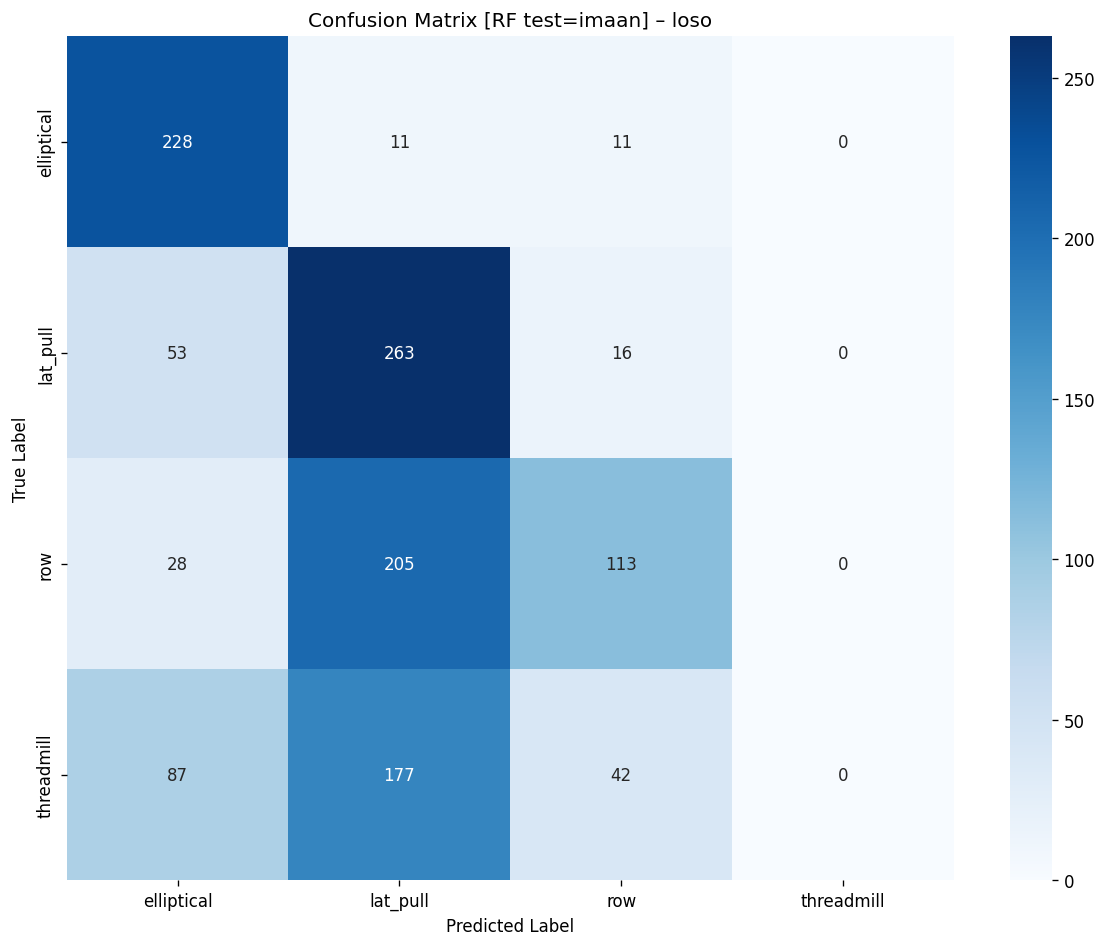


  LOSO fold: test=richard  (train=1234, test=524)

Test Accuracy [RF test=richard]: 0.3721
              precision    recall  f1-score   support

  elliptical       0.99      0.25      0.39       300
    lat_pull       0.54      0.07      0.12       105
         row       0.26      0.96      0.41       119
  threadmill       0.00      0.00      0.00         0

    accuracy                           0.37       524
   macro avg       0.45      0.32      0.23       524
weighted avg       0.73      0.37      0.34       524



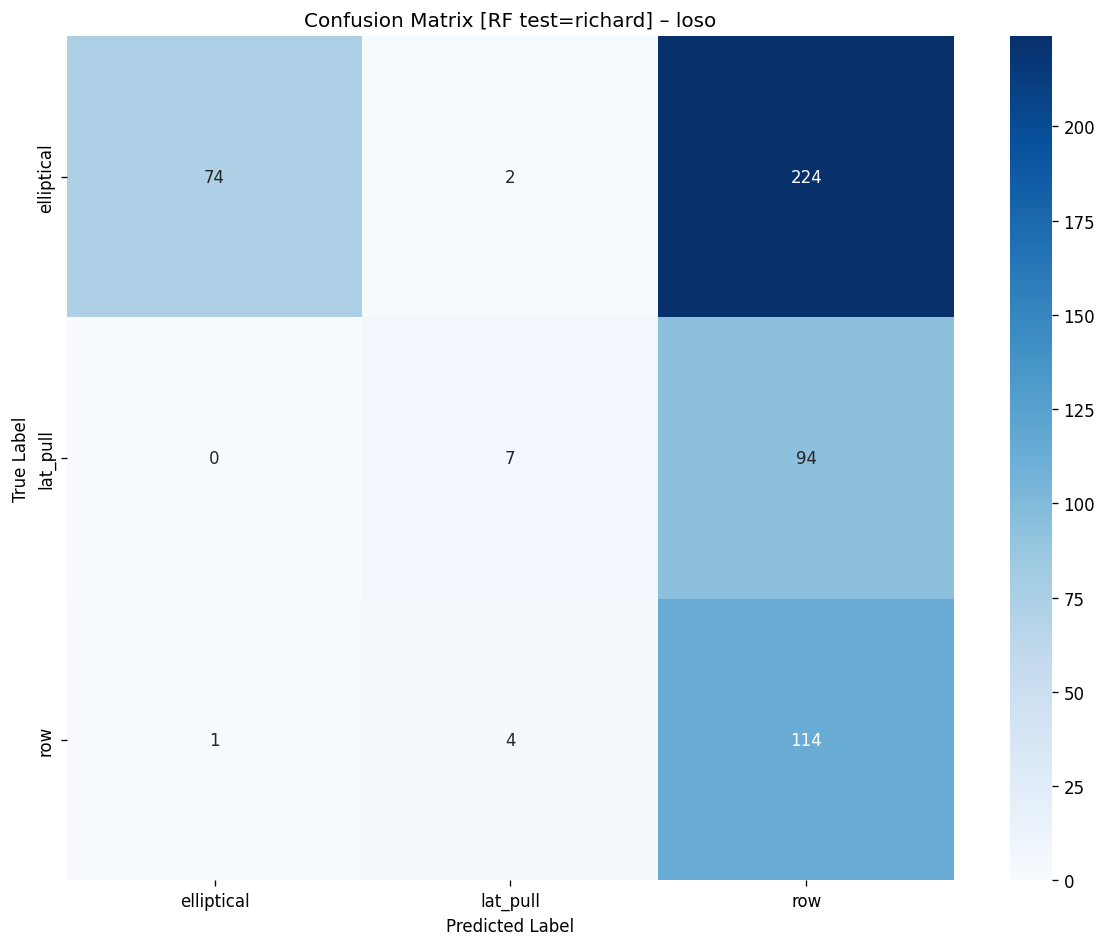


  LOSO Mean Accuracy (RF): 0.4308
  Per-fold: {'imaan': 0.48946515397082657, 'richard': 0.37213740458015265}

  SVM – LOSO

=== Training [SVM] with [loso] validation ===

  LOSO fold: test=imaan  (train=524, test=1234)

Test Accuracy [SVM test=imaan]: 0.2699
              precision    recall  f1-score   support

  elliptical       0.44      0.05      0.09       250
    lat_pull       0.38      0.88      0.53       332
         row       0.07      0.08      0.07       346
  threadmill       0.00      0.00      0.00       306

    accuracy                           0.27      1234
   macro avg       0.22      0.25      0.17      1234
weighted avg       0.21      0.27      0.18      1234



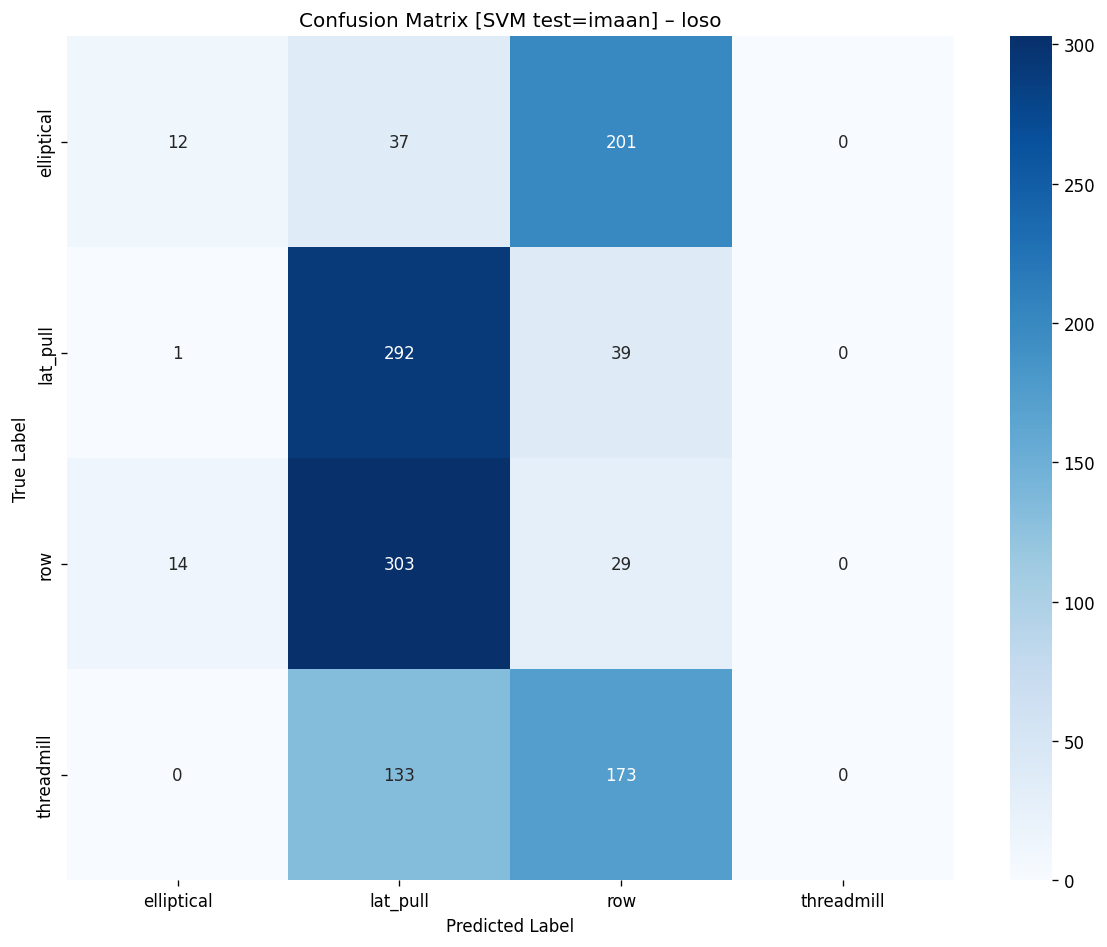


  LOSO fold: test=richard  (train=1234, test=524)

Test Accuracy [SVM test=richard]: 0.4332
              precision    recall  f1-score   support

  elliptical       0.52      0.68      0.59       300
    lat_pull       1.00      0.02      0.04       105
         row       0.15      0.17      0.16       119

    accuracy                           0.43       524
   macro avg       0.56      0.29      0.26       524
weighted avg       0.53      0.43      0.38       524



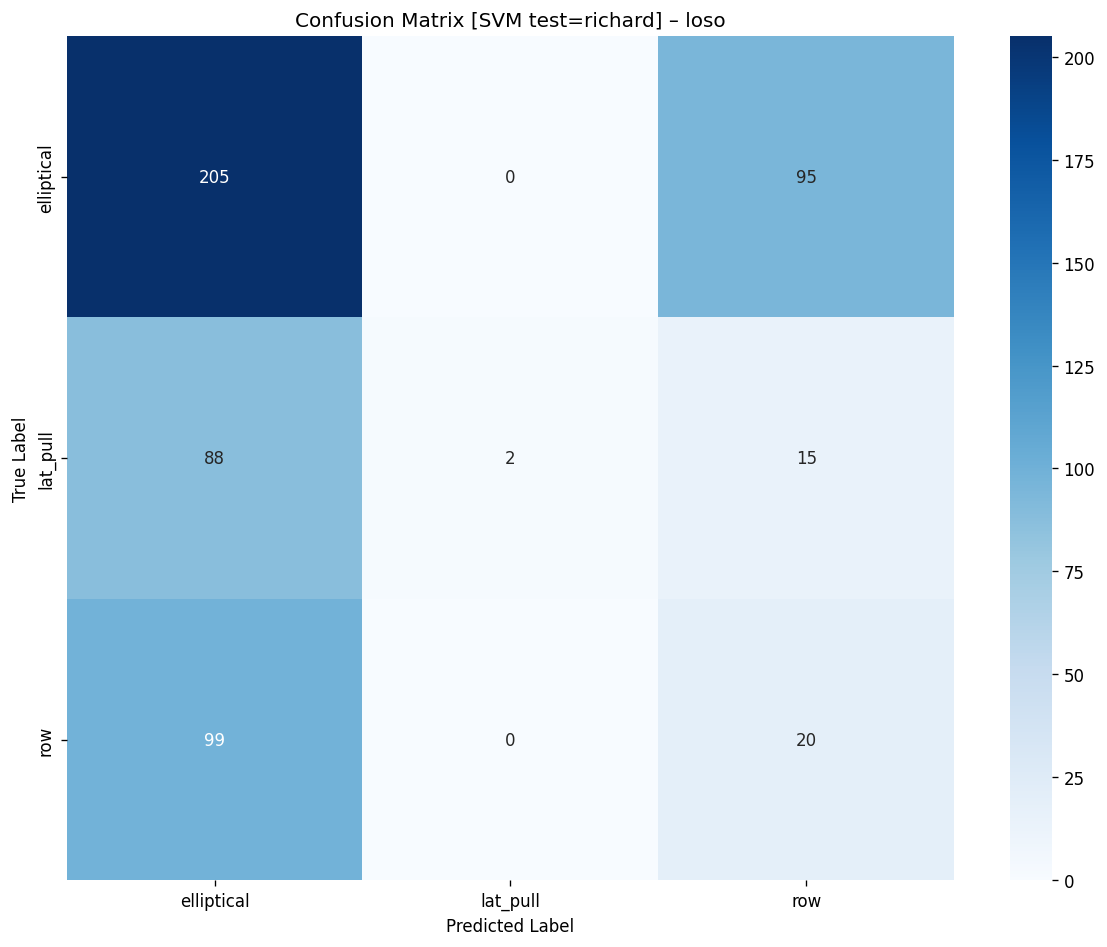


  LOSO Mean Accuracy (SVM): 0.3515
  Per-fold: {'imaan': 0.2698541329011345, 'richard': 0.43320610687022904}

  GBM – LOSO

=== Training [GBM] with [loso] validation ===

  LOSO fold: test=imaan  (train=524, test=1234)

Test Accuracy [GBM test=imaan]: 0.4441
              precision    recall  f1-score   support

  elliptical       0.45      0.48      0.47       250
    lat_pull       0.37      0.62      0.46       332
         row       0.54      0.64      0.59       346
  threadmill       0.00      0.00      0.00       306

    accuracy                           0.44      1234
   macro avg       0.34      0.44      0.38      1234
weighted avg       0.34      0.44      0.38      1234



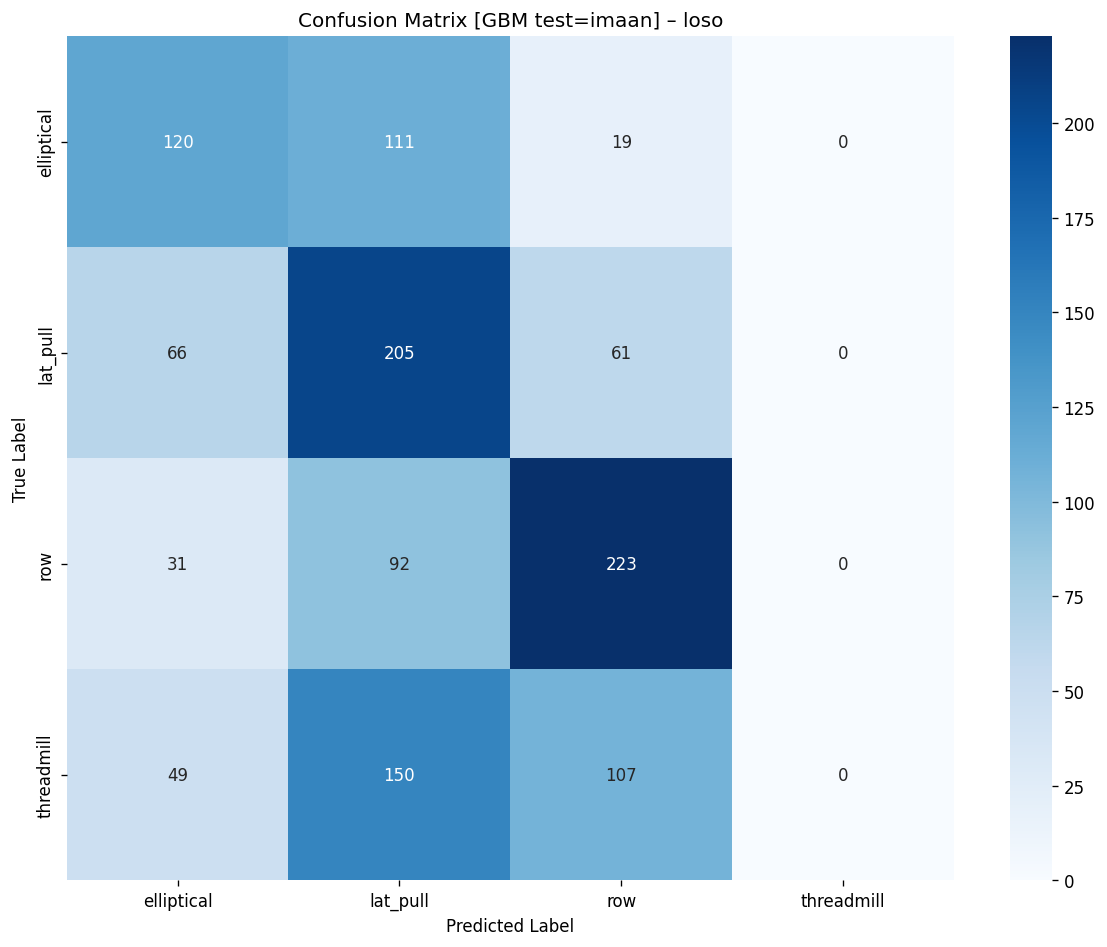


  LOSO fold: test=richard  (train=1234, test=524)

Test Accuracy [GBM test=richard]: 0.2042
              precision    recall  f1-score   support

  elliptical       1.00      0.00      0.01       300
    lat_pull       0.52      0.31      0.39       105
         row       0.21      0.61      0.32       119
  threadmill       0.00      0.00      0.00         0

    accuracy                           0.20       524
   macro avg       0.43      0.23      0.18       524
weighted avg       0.72      0.20      0.15       524



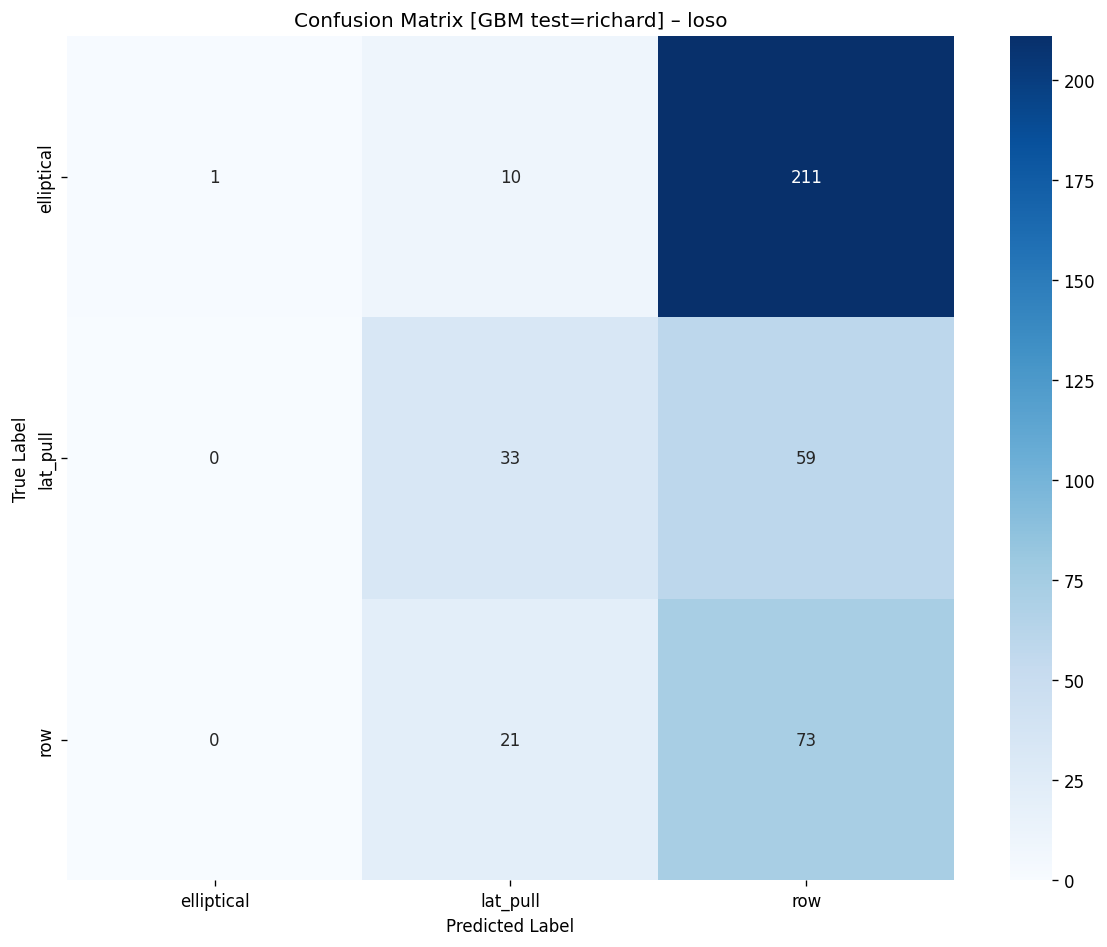


  LOSO Mean Accuracy (GBM): 0.3241
  Per-fold: {'imaan': 0.44408427876823336, 'richard': 0.20419847328244276}

=== Classical Model LOSO Summary ===
  RF  : mean LOSO accuracy = 0.4308  | per-fold = {'imaan': 0.48946515397082657, 'richard': 0.37213740458015265}
  SVM : mean LOSO accuracy = 0.3515  | per-fold = {'imaan': 0.2698541329011345, 'richard': 0.43320610687022904}
  GBM : mean LOSO accuracy = 0.3241  | per-fold = {'imaan': 0.44408427876823336, 'richard': 0.20419847328244276}


In [27]:

# ── 6. CLASSICAL ML – LOSO EVALUATION (Point 5) ──────────────────────────────
# Evaluation split: Leave-One-Subject-Out
# Train on participant A → test on participant B, and vice versa.
# This measures generalisation to an unseen person, as required by the brief.

classical_results = {}
classical_models = {}

for model_type in ["rf", "svm", "gbm"]:
    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} – LOSO")
    print(f"{'='*60}")
    trained_model, trained_scaler, res = train_with_validation(
        features, labels, feature_names, metadata,
        validation_strategy="loso",
        model_type=model_type,
    )
    classical_results[model_type] = res
    classical_models[model_type] = (trained_model, trained_scaler)

rf_model = classical_models["rf"][0]

print("\n=== Classical Model LOSO Summary ===")
for mt, res in classical_results.items():
    print(f"  {mt.upper():4s}: mean LOSO accuracy = {res['mean_accuracy']:.4f}  "
          f"| per-fold = {res['per_fold_accuracy']}")



Gym Movements Deep Learning Pipeline (LOSO Evaluation)

Loading Gym Movements Dataset...
Gym Movements Dataset loaded:
  Total samples : 118,031
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'row', 'threadmill']
  Sessions      : 59
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'mag_x', 'mag_y', 'mag_z', 'activity_label', 'participant', 'session', 'data_source']
Total samples: 118031
Participants: ['imaan', 'richard']
Activities: ['elliptical', 'lat_pull', 'row', 'threadmill']

=== Missing Value Analysis ===
Missing values per channel:
acc_x      0
acc_y      0
acc_z      0
gyro_x    25
gyro_y    25
gyro_z    25

Total missing: 75 — applying linear interpolation per session

Creating adaptive windows...

Window creation summary:
  Full-size windows: 1758
  Adaptive windows: 0
  Rejecte

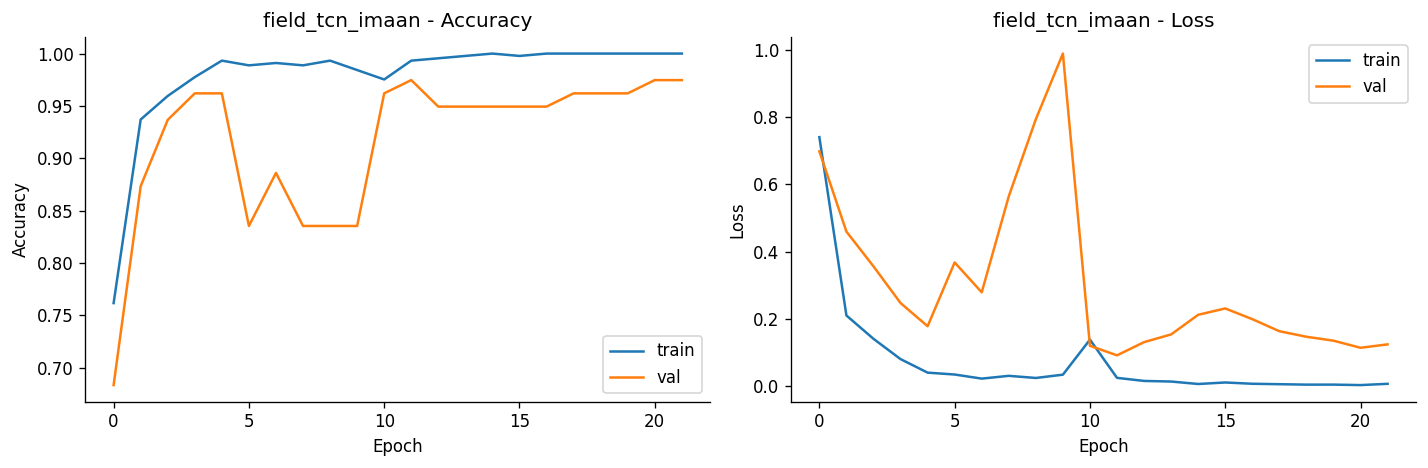


Training LSTM (test=imaan)...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.4831 - loss: 1.3020 - val_accuracy: 0.6329 - val_loss: 1.1025 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.6989 - loss: 0.9297 - val_accuracy: 0.7089 - val_loss: 0.6922 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.7888 - loss: 0.5287 - val_accuracy: 0.8481 - val_loss: 0.3387 - learning_rate: 0.0010
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.8427 - loss: 0.3363 - val_accuracy: 0.8481 - val_loss: 0.3647 - learning_rate: 0.0010
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.8989 - loss: 0.2827 - val_accuracy: 0.8861 - val_loss: 0.3306 - learning_rate: 0.0010
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9506 - loss: 0.1963 - val_accuracy: 0.9241 - val_loss: 0.2526 - learning_rate: 0.0010
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy:

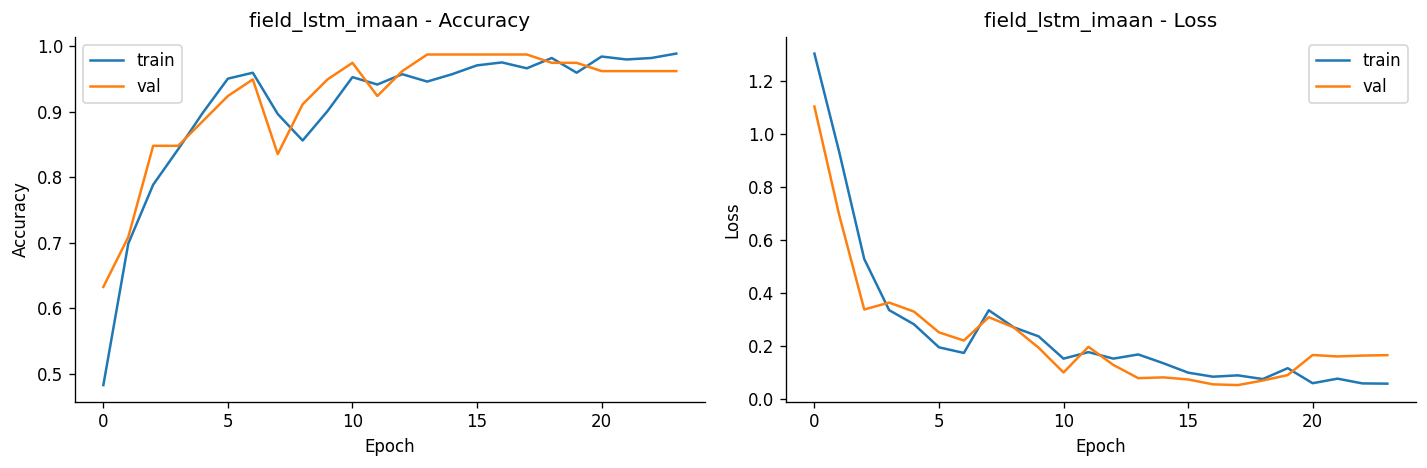


Training CNN_LSTM (test=imaan)...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.4809 - loss: 1.1908 - val_accuracy: 0.5696 - val_loss: 1.1500 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7820 - loss: 0.7105 - val_accuracy: 0.5696 - val_loss: 0.9622 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8449 - loss: 0.4053 - val_accuracy: 0.5696 - val_loss: 1.6711 - learning_rate: 0.0010
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9191 - loss: 0.2722 - val_accuracy: 0.8101 - val_loss: 0.5965 - learning_rate: 0.0010
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9461 - loss: 0.1764 - val_accuracy: 0.8481 - val_loss: 0.3030 - learning_rate: 0.0010
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9640 - loss: 0.1200 - val_accuracy: 0.9494 - val_loss: 0.2169 - learning_rate: 0.0010
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accura

In [ ]:
# ── 7. DEEP LEARNING – LOSO EVALUATION (Point 6) ─────────────────────────────
# TCN, LSTM, CNN-LSTM trained on raw sequences with LOSO split.
# Uses Python.posthoc.get_training_summary which:
#   - reloads raw data
#   - handles missing values
#   - creates windows and sequences
#   - runs LOSO evaluation for all three DL models
#   - saves results + plots

from Python.posthoc import get_training_summary

dl_results, dl_summary = get_training_summary(rf_model=rf_model)

print("\n=== Deep Learning LOSO Summary ===")
for mt, s in dl_summary.items():
    print(f"  {mt.upper():10s}: mean LOSO accuracy = {s['mean']:.4f}")


=== Per-Activity Classification Report (RF LOSO, all folds) ===
              precision    recall  f1-score   support

  elliptical       0.64      0.55      0.59       550
    lat_pull       0.40      0.62      0.49       437
         row       0.37      0.49      0.42       465
  threadmill       0.00      0.00      0.00       306

    accuracy                           0.45      1758
   macro avg       0.35      0.41      0.38      1758
weighted avg       0.40      0.45      0.42      1758



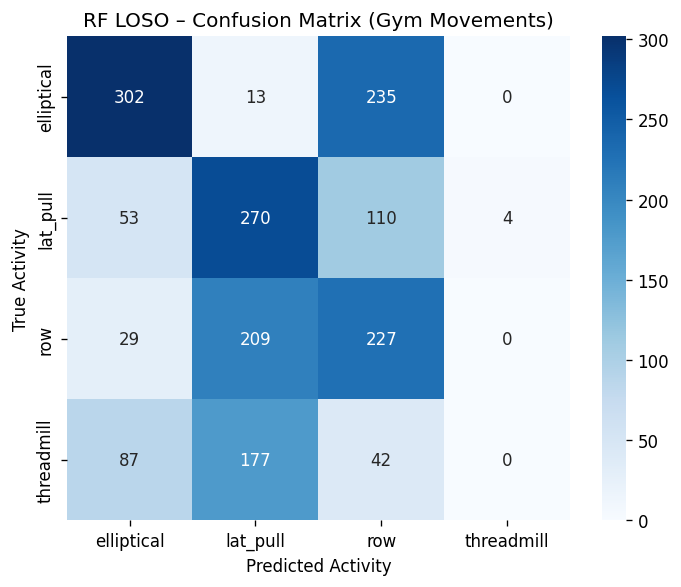


Samples per activity (windows):
  elliptical     : 550
  lat_pull       : 437
  row            : 465
  threadmill     : 306


In [ ]:
# ── 8. PER-ACTIVITY ACCURACY BREAKDOWN ───────────────────────────────────────
# Analyse which gym movement is hardest to classify by looking at per-class
# precision / recall from the aggregated LOSO predictions of the best classical model.

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Use the RF LOSO predictions (all folds combined)
rf_res = classical_results["rf"]
y_true_all = np.array(rf_res["all_true"])
y_pred_all = np.array(rf_res["all_pred"])
activities = sorted(set(y_true_all))

print("=== Per-Activity Classification Report (RF LOSO, all folds) ===")
print(classification_report(y_true_all, y_pred_all, target_names=activities, zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true_all, y_pred_all, labels=activities)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=activities, yticklabels=activities, ax=ax,
)
ax.set_title("RF LOSO – Confusion Matrix (Gym Movements)")
ax.set_ylabel("True Activity")
ax.set_xlabel("Predicted Activity")
plt.tight_layout()
plt.savefig("./Plots/gym_rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Per-activity sample counts
print("\nSamples per activity (windows):")
unique, counts = np.unique(y_true_all, return_counts=True)
for act, cnt in zip(unique, counts):
    print(f"  {act:<15s}: {cnt}")


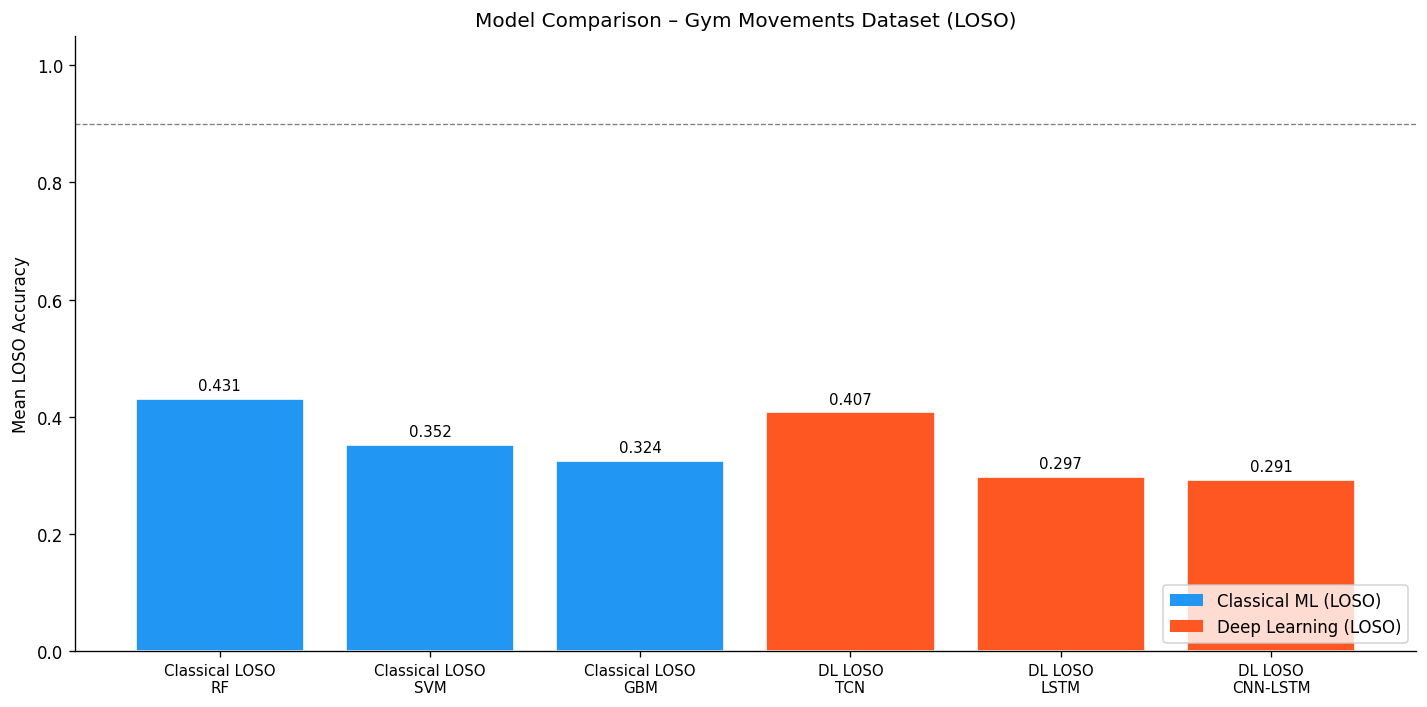


=== Final Results Table ===
Model                            Mean LOSO Accuracy
----------------------------------------------------
Classical LOSO – RF                                    0.4308
Classical LOSO – SVM                                   0.3515
Classical LOSO – GBM                                   0.3241
DL LOSO – TCN                                          0.4072
DL LOSO – LSTM                                         0.2967
DL LOSO – CNN-LSTM                                     0.2915


In [ ]:
# ── 9. MODEL COMPARISON VISUALISATION ────────────────────────────────────────

# Collect results
all_accs = {}

# Classical LOSO
for mt, res in classical_results.items():
    all_accs[f"Classical LOSO\n{mt.upper()}"] = res["mean_accuracy"]

# Deep learning LOSO
for mt, s in dl_summary.items():
    label = {"tcn": "TCN", "lstm": "LSTM", "cnn_lstm": "CNN-LSTM"}.get(mt, mt.upper())
    all_accs[f"DL LOSO\n{label}"] = s["mean"]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
colors = (
    ["#2196F3"] * len(classical_results)
    + ["#FF5722"] * len(dl_summary)
)
bars = ax.bar(list(all_accs.keys()), list(all_accs.values()), color=colors, edgecolor="white")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean LOSO Accuracy")
ax.set_title("Model Comparison – Gym Movements Dataset (LOSO)")
ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8, label="0.90 reference")

for bar, val in zip(bars, all_accs.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{val:.3f}", ha="center", va="bottom", fontsize=9,
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Classical ML (LOSO)"),
    Patch(facecolor="#FF5722", label="Deep Learning (LOSO)"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.xticks(rotation=0, ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("./Plots/gym_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Final Results Table ===")
print(f"{'Model':<30} {'Mean LOSO Accuracy':>20}")
print("-" * 52)
for name, acc in all_accs.items():
    label = name.replace("\n", " – ")
    print(f"{label:<50} {acc:>10.4f}")
